
Reading FITS file: ./PS2_posterior_pure_trained_ska.fits
Posterior data shape (N_ax3, N_ax2, N_ax1): (100, 100, 100)
Using 861 grid points out of 1000000 for corner plot (weight > 1.16e-11)
Generating corner plot...


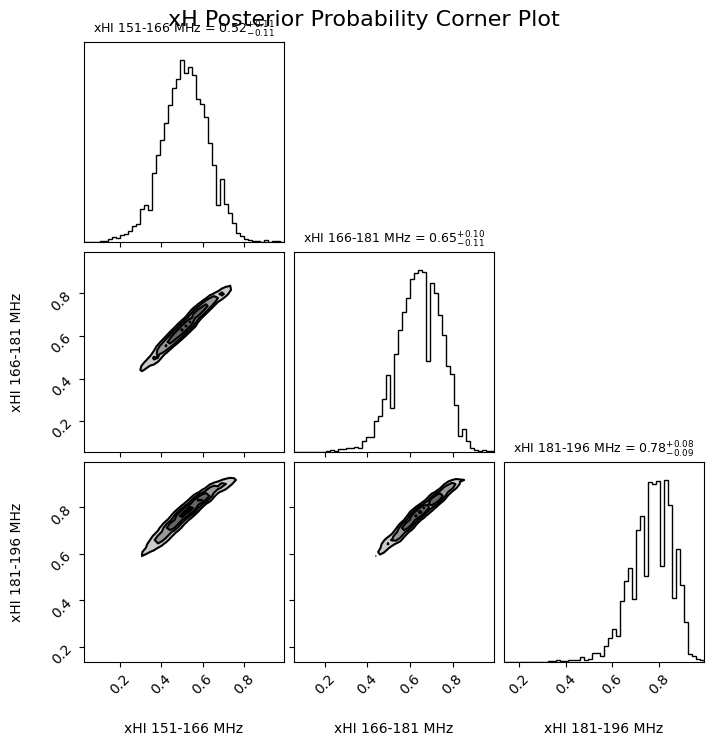

In [21]:
import numpy as np
import corner
from astropy.io import fits
import os
import matplotlib.pyplot as plt


def generate_corner_plot(fits_filepath, output_image_file=None):
    try:
        with fits.open(fits_filepath) as hdul:
            hdu = hdul[0]
            header = hdu.header
            posterior_data = hdu.data # This will be (NAXIS3, NAXIS2, NAXIS1)

            print(f"\nReading FITS file: {fits_filepath}")
            print(f"Posterior data shape (N_ax3, N_ax2, N_ax1): {posterior_data.shape}")

            # Get axis information for the 3 parameters of the corner plot
            # Parameter 1: Corresponds to FITS NAXIS1
            # Parameter 2: Corresponds to FITS NAXIS2
            # Parameter 3: Corresponds to FITS NAXIS3
            params_info = [
                {'label': header.get('HIERARCH AXIS1-FREQ', 'xH Param1'),
                 'nval': header['NAXIS1'], 'crval': header['CRVAL1'],
                 'crpix': header['CRPIX1'], 'cdelt': header['CDELT1']},
                {'label': header.get('HIERARCH AXIS2-FREQ', 'xH Param2'),
                 'nval': header['NAXIS2'], 'crval': header['CRVAL2'],
                 'crpix': header['CRPIX2'], 'cdelt': header['CDELT2']},
                {'label': header.get('HIERARCH AXIS3-FREQ', 'xH Param3'),
                 'nval': header['NAXIS3'], 'crval': header['CRVAL3'],
                 'crpix': header['CRPIX3'], 'cdelt': header['CDELT3']}
            ]

            # Create 1D arrays of xH values for each parameter/axis
            xh_coords = []
            for info in params_info:
                # Physical_Value = CRVAL + (Index_Python - (CRPIX - 1)) * CDELT
                # Index_Python runs from 0 to NVAL-1
                coords = info['crval'] + (np.arange(info['nval']) - (info['crpix'] - 1)) * info['cdelt']
                xh_coords.append(coords)
            
            xh_p1_vals = xh_coords[0] # Values for FITS NAXIS1
            xh_p2_vals = xh_coords[1] # Values for FITS NAXIS2
            xh_p3_vals = xh_coords[2] # Values for FITS NAXIS3

            # Create a meshgrid of xH coordinates.
            # posterior_data[k, j, i] corresponds to (xh_p3_vals[k], xh_p2_vals[j], xh_p1_vals[i])
            # We need grid arrays that match this data indexing for easy flattening.
            # `indexing='ij'` makes MESH_p3[k,j,i] = xh_p3_vals[k], etc.
            MESH_p3, MESH_p2, MESH_p1 = np.meshgrid(xh_p3_vals, xh_p2_vals, xh_p1_vals, indexing='ij')

            # Prepare samples for the corner plot.
            # Each row in `samples_for_corner` is a point (param1_val, param2_val, param3_val).
            # The order of columns here determines the order of parameters in the plot.
            samples_for_corner = np.vstack([
                MESH_p1.ravel(),  # Parameter 1 values (from FITS NAXIS1)
                MESH_p2.ravel(),  # Parameter 2 values (from FITS NAXIS2)
                MESH_p3.ravel()   # Parameter 3 values (from FITS NAXIS3)
            ]).T

            # Weights are the posterior probabilities at each grid point
            weights_for_corner = posterior_data.ravel()

            # Filter out samples with zero or negligible probability to speed up corner plot
            # and avoid issues with KDE if many weights are exactly zero.
            # This threshold can be adjusted.
            threshold = 1e-9 * np.max(weights_for_corner) # or a small absolute value
            valid_indices = weights_for_corner > threshold
            
            if np.sum(valid_indices) == 0 :
                print("Warning: All probability weights are below threshold. Plotting all points.")
            else:
                print(f"Using {np.sum(valid_indices)} grid points out of {len(weights_for_corner)} for corner plot (weight > {threshold:.2e})")
                samples_for_corner = samples_for_corner[valid_indices]
                weights_for_corner = weights_for_corner[valid_indices]


            plot_labels = [info['label'] for info in params_info]

            print("Generating corner plot...")
            fig = corner.corner(
                samples_for_corner,
                weights=weights_for_corner,
                labels=plot_labels,
                show_titles=True,                # Show median and quantiles in titles
                title_quantiles=[0.16, 0.5, 0.84], # 1-sigma credible interval
                plot_datapoints=False,           # We are using weighted grid points
                plot_density=True,               # Plot KDE smooth density
                plot_contours=True,              # Show 2D contours
                fill_contours=True,              # Fill 2D contours
                bins=50,                         # Bins for histograms
                smooth=0.7,                      # Smoothing for KDE
                label_kwargs=dict(fontsize=10),
                title_kwargs=dict(fontsize=9)
            )

            fig.suptitle("xH Posterior Probability Corner Plot", fontsize=16, y=0.99)
            # plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle

            if output_image_file:
                plt.savefig(output_image_file, dpi=300, bbox_inches='tight')
                print(f"Corner plot saved to {output_image_file}")
            else:
                plt.show()

    except FileNotFoundError: # Should be caught by the check above, but good to have
        print(f"Error: FITS file not found at '{fits_filepath}' during processing.")
    except Exception as e:
        print(f"An error occurred while generating the corner plot: {e}")
        import traceback
        traceback.print_exc()

# --- Main execution ---
if __name__ == "__main__":
    fits_file_to_analyze = './PS2_posterior_pure_trained_ska.fits' 
    
    # Generate and show the corner plot 
    generate_corner_plot(fits_file_to_analyze)


Reading FITS file: ./PS2_posterior_pure_trained.fits
Posterior data shape (N_ax3, N_ax2, N_ax1): (100, 100, 100)
Using 630 grid points out of 1000000 for corner plot (weight > 2.38e-11)
Generating corner plot...


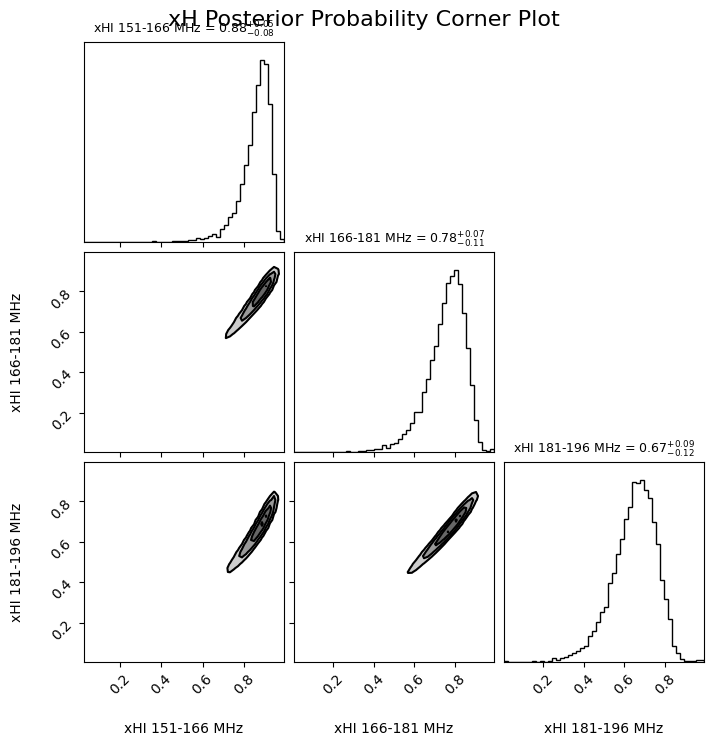

In [19]:
import numpy as np
import corner
from astropy.io import fits
import os
import matplotlib.pyplot as plt


def generate_corner_plot(fits_filepath, output_image_file=None):
    try:
        with fits.open(fits_filepath) as hdul:
            hdu = hdul[0]
            header = hdu.header
            posterior_data = hdu.data # This will be (NAXIS3, NAXIS2, NAXIS1)

            print(f"\nReading FITS file: {fits_filepath}")
            print(f"Posterior data shape (N_ax3, N_ax2, N_ax1): {posterior_data.shape}")

            # Get axis information for the 3 parameters of the corner plot
            # Parameter 1: Corresponds to FITS NAXIS1
            # Parameter 2: Corresponds to FITS NAXIS2
            # Parameter 3: Corresponds to FITS NAXIS3
            params_info = [
                {'label': header.get('HIERARCH AXIS1-FREQ', 'xH Param1'),
                 'nval': header['NAXIS1'], 'crval': header['CRVAL1'],
                 'crpix': header['CRPIX1'], 'cdelt': header['CDELT1']},
                {'label': header.get('HIERARCH AXIS2-FREQ', 'xH Param2'),
                 'nval': header['NAXIS2'], 'crval': header['CRVAL2'],
                 'crpix': header['CRPIX2'], 'cdelt': header['CDELT2']},
                {'label': header.get('HIERARCH AXIS3-FREQ', 'xH Param3'),
                 'nval': header['NAXIS3'], 'crval': header['CRVAL3'],
                 'crpix': header['CRPIX3'], 'cdelt': header['CDELT3']}
            ]

            # Create 1D arrays of xH values for each parameter/axis
            xh_coords = []
            for info in params_info:
                # Physical_Value = CRVAL + (Index_Python - (CRPIX - 1)) * CDELT
                # Index_Python runs from 0 to NVAL-1
                coords = info['crval'] + (np.arange(info['nval']) - (info['crpix'] - 1)) * info['cdelt']
                xh_coords.append(coords)
            
            xh_p1_vals = xh_coords[0] # Values for FITS NAXIS1
            xh_p2_vals = xh_coords[1] # Values for FITS NAXIS2
            xh_p3_vals = xh_coords[2] # Values for FITS NAXIS3

            # Create a meshgrid of xH coordinates.
            # posterior_data[k, j, i] corresponds to (xh_p3_vals[k], xh_p2_vals[j], xh_p1_vals[i])
            # We need grid arrays that match this data indexing for easy flattening.
            # `indexing='ij'` makes MESH_p3[k,j,i] = xh_p3_vals[k], etc.
            MESH_p3, MESH_p2, MESH_p1 = np.meshgrid(xh_p3_vals, xh_p2_vals, xh_p1_vals, indexing='ij')

            # Prepare samples for the corner plot.
            # Each row in `samples_for_corner` is a point (param1_val, param2_val, param3_val).
            # The order of columns here determines the order of parameters in the plot.
            samples_for_corner = np.vstack([
                MESH_p1.ravel(),  # Parameter 1 values (from FITS NAXIS1)
                MESH_p2.ravel(),  # Parameter 2 values (from FITS NAXIS2)
                MESH_p3.ravel()   # Parameter 3 values (from FITS NAXIS3)
            ]).T

            # Weights are the posterior probabilities at each grid point
            weights_for_corner = posterior_data.ravel()

            # Filter out samples with zero or negligible probability to speed up corner plot
            # and avoid issues with KDE if many weights are exactly zero.
            # This threshold can be adjusted.
            threshold = 1e-9 * np.max(weights_for_corner) # or a small absolute value
            valid_indices = weights_for_corner > threshold
            
            if np.sum(valid_indices) == 0 :
                print("Warning: All probability weights are below threshold. Plotting all points.")
            else:
                print(f"Using {np.sum(valid_indices)} grid points out of {len(weights_for_corner)} for corner plot (weight > {threshold:.2e})")
                samples_for_corner = samples_for_corner[valid_indices]
                weights_for_corner = weights_for_corner[valid_indices]


            plot_labels = [info['label'] for info in params_info]

            print("Generating corner plot...")
            fig = corner.corner(
                samples_for_corner,
                weights=weights_for_corner,
                labels=plot_labels,
                show_titles=True,                # Show median and quantiles in titles
                title_quantiles=[0.16, 0.5, 0.84], # 1-sigma credible interval
                plot_datapoints=False,           # We are using weighted grid points
                plot_density=True,               # Plot KDE smooth density
                plot_contours=True,              # Show 2D contours
                fill_contours=True,              # Fill 2D contours
                bins=50,                         # Bins for histograms
                smooth=0.7,                      # Smoothing for KDE
                label_kwargs=dict(fontsize=10),
                title_kwargs=dict(fontsize=9)
            )

            fig.suptitle("xH Posterior Probability Corner Plot", fontsize=16, y=0.99)
            # plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle

            if output_image_file:
                plt.savefig(output_image_file, dpi=300, bbox_inches='tight')
                print(f"Corner plot saved to {output_image_file}")
            else:
                plt.show()

    except FileNotFoundError: # Should be caught by the check above, but good to have
        print(f"Error: FITS file not found at '{fits_filepath}' during processing.")
    except Exception as e:
        print(f"An error occurred while generating the corner plot: {e}")
        import traceback
        traceback.print_exc()

# --- Main execution ---
if __name__ == "__main__":
    fits_file_to_analyze = './PS2_posterior_pure_trained.fits' 
    
    # Generate and show the corner plot 
    generate_corner_plot(fits_file_to_analyze)